**1. Import Libraries**

In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

**2. Upload the Dataset**

In [206]:
dataset=pd.read_csv("dataset/Airport_MHE_Final_Dataset.csv")
dataset

,Record_Date,Equipment_ID,Equipment_Type,Fleet_Category,Manufacturer,Fuel_Type,Equipment_Age_Year,Daily_Operating_Hours,ULD_Handling_Count,Consecutive_Working_Days,...,Breakdown_Count_6M,Operator_Experience_Years,Battery_Status,Hydraulic_Leak_Observed,Warehouse_Zone,Outdoor_Usage,Warning_Indicator_Count,Downtime_Hours_Last_30D,Peak_Hour_Operations,Failure_Risk_Level
0,2023-05-01,F-006,Forklift,Warehouse,Hyster,Electric,1.9,9,62,11,...,0,11,Critical,No,Cold Storage,Yes,0,0,Yes,Low
1,2023-05-01,F-008,Forklift,Ramp,Caterpillar,Diesel,4.3,9,71,4,...,0,8,Critical,No,Import,Yes,1,0,No,Low
2,2023-05-01,F-009,Forklift,Ramp,Caterpillar,Electric,2.2,10,23,8,...,0,3,Critical,No,Cold Storage,No,0,0,Yes,Low
3,2023-05-01,F-010,Forklift,Warehouse,Hyster,Electric,4.4,9,57,6,...,0,15,Critical,No,Import,Yes,0,0,Yes,Low
4,2023-05-01,F-011,Forklift,Warehouse,TLD,Electric,7.0,9,75,9,...,0,11,Critical,No,General Cargo,No,1,0,No,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34233,2026-04-30,UT-074,ULD Transporter,Cargo,Jungheinrich,Diesel,4.4,14,54,20,...,141,14,Good,Yes,General Cargo,No,8,15,No,Medium
34234,2026-04-30,BL-038,Belt Loader,Ramp,Jungheinrich,Electric,10.2,15,40,15,...,136,1,Good,Yes,Import,Yes,8,6,No,Medium
34235,2026-04-30,F-015,Forklift,Warehouse,Jungheinrich,Electric,6.3,15,17,18,...,262,15,Good,No,Export,Yes,8,7,No,Low
34236,2026-04-30,F-022,Forklift,Cargo,Jungheinrich,Diesel,4.5,12,58,17,...,255,14,Good,Yes,Export,Yes,8,3,No,High


In [244]:
noise_idx = dataset.sample(
    frac=0.05,
    random_state=42
).index

# Available classes
classes = ['Low', 'Medium', 'High']

# Replace selected rows with random classes
dataset.loc[noise_idx, 'Failure_Risk_Level'] = np.random.choice(
    classes,
    size=len(noise_idx)
)

**3. Basic Checkups**

In [245]:
dataset['Failure_Risk_Level'].value_counts()

Failure_Risk_Level
Low       21738
Medium     7795
High       4705
Name: count, dtype: int64

In [246]:
# Shape
print("Shape of the dataset:")
print(dataset.shape)
print("\n")


# Columns
print("Columns in the dataset:")
print(dataset.columns)

Shape of the dataset:
(34238, 26)


Columns in the dataset:
Index(['Record_Date', 'Equipment_ID', 'Equipment_Type', 'Fleet_Category',
       'Manufacturer', 'Fuel_Type', 'Equipment_Age_Year',
       'Daily_Operating_Hours', 'ULD_Handling_Count',
       'Consecutive_Working_Days', 'Cargo_Weight_Handled_KG',
       'Overload_Event_Count', 'Breakdown_Count_6M',
       'Operator_Experience_Years', 'Battery_Status',
       'Hydraulic_Leak_Observed', 'Warehouse_Zone', 'Outdoor_Usage',
       'Warning_Indicator_Count', 'Downtime_Hours_Last_30D',
       'Peak_Hour_Operations', 'Failure_Risk_Level', 'Month_Year', 'Year',
       'Month', 'Quarter'],
      dtype='str')


In [247]:
#check the null values in the dataset
dataset.isnull().sum()

Record_Date                  0
Equipment_ID                 0
Equipment_Type               0
Fleet_Category               0
Manufacturer                 0
Fuel_Type                    0
Equipment_Age_Year           0
Daily_Operating_Hours        0
ULD_Handling_Count           0
Consecutive_Working_Days     0
Cargo_Weight_Handled_KG      0
Overload_Event_Count         0
Breakdown_Count_6M           0
Operator_Experience_Years    0
Battery_Status               0
Hydraulic_Leak_Observed      0
Warehouse_Zone               0
Outdoor_Usage                0
Warning_Indicator_Count      0
Downtime_Hours_Last_30D      0
Peak_Hour_Operations         0
Failure_Risk_Level           0
Month_Year                   0
Year                         0
Month                        0
Quarter                      0
dtype: int64

In [248]:
#information about the dataset
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 34238 entries, 0 to 34237
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Record_Date                34238 non-null  datetime64[us]
 1   Equipment_ID               34238 non-null  str           
 2   Equipment_Type             34238 non-null  str           
 3   Fleet_Category             34238 non-null  str           
 4   Manufacturer               34238 non-null  str           
 5   Fuel_Type                  34238 non-null  str           
 6   Equipment_Age_Year         34238 non-null  float64       
 7   Daily_Operating_Hours      34238 non-null  int64         
 8   ULD_Handling_Count         34238 non-null  int64         
 9   Consecutive_Working_Days   34238 non-null  int64         
 10  Cargo_Weight_Handled_KG    34238 non-null  int64         
 11  Overload_Event_Count       34238 non-null  int64         
 12  Breakdown_Count

In [249]:
#statistical summary of the dataset
dataset.describe()

,Record_Date,Equipment_Age_Year,Daily_Operating_Hours,ULD_Handling_Count,Consecutive_Working_Days,Cargo_Weight_Handled_KG,Overload_Event_Count,Breakdown_Count_6M,Operator_Experience_Years,Warning_Indicator_Count,Downtime_Hours_Last_30D,Year,Month,Quarter
count,34238,34238.000000,34238.000000,34238.000000,34238.000000,34238.000000,34238.000000,34238.000000,34238.000000,34238.000000,34238.000000,34238.000000,34238.000000,34238.000000
mean,2024-10-28 17:14:18.204334,5.830303,12.970004,44.879841,14.551463,22504.068316,6.213067,94.436270,7.965010,6.088819,4.908756,2024.326129,6.524008,2.509989
min,2023-01-05 00:00:00,0.400000,8.000000,15.000000,2.000000,4500.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2023.000000,1.000000,1.000000
25%,2024-01-29 00:00:00,4.000000,12.000000,30.000000,12.000000,14081.000000,5.000000,40.000000,4.000000,5.000000,1.000000,2024.000000,4.000000,2.000000
50%,2024-10-28 00:00:00,5.900000,13.000000,45.000000,15.000000,21286.000000,7.000000,87.000000,8.000000,7.000000,3.000000,2024.000000,7.000000,3.000000
75%,2025-07-30 00:00:00,7.700000,14.000000,60.000000,17.000000,29512.000000,8.000000,136.000000,12.000000,8.000000,7.000000,2025.000000,10.000000,4.000000
max,2026-12-04 00:00:00,11.300000,16.000000,75.000000,28.000000,52500.000000,8.000000,279.000000,15.000000,8.000000,25.000000,2026.000000,12.000000,4.000000
std,NaN,2.371769,1.841883,17.563126,3.847180,10391.090657,2.201563,65.308798,4.326565,2.353422,4.958545,0.942337,3.443686,1.114290


**4. Exploratory Data Analysis**

4.1 Target Distribution

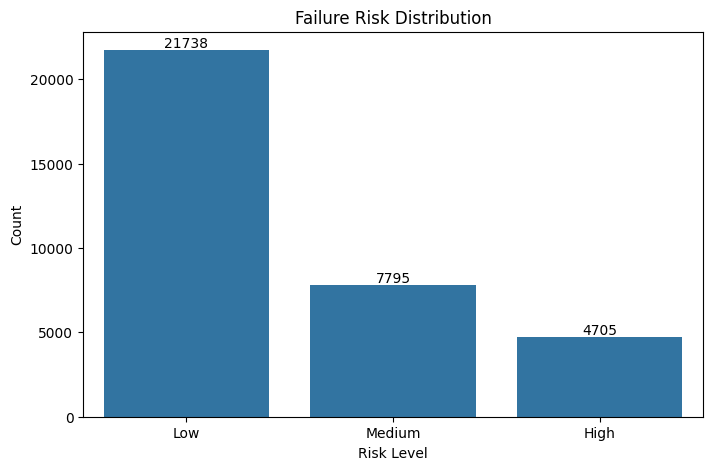

In [250]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Failure_Risk_Level',
    data=dataset,
    order=['Low','Medium','High']
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Failure Risk Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')

plt.show()

4.2 Equipment type vs failure risk

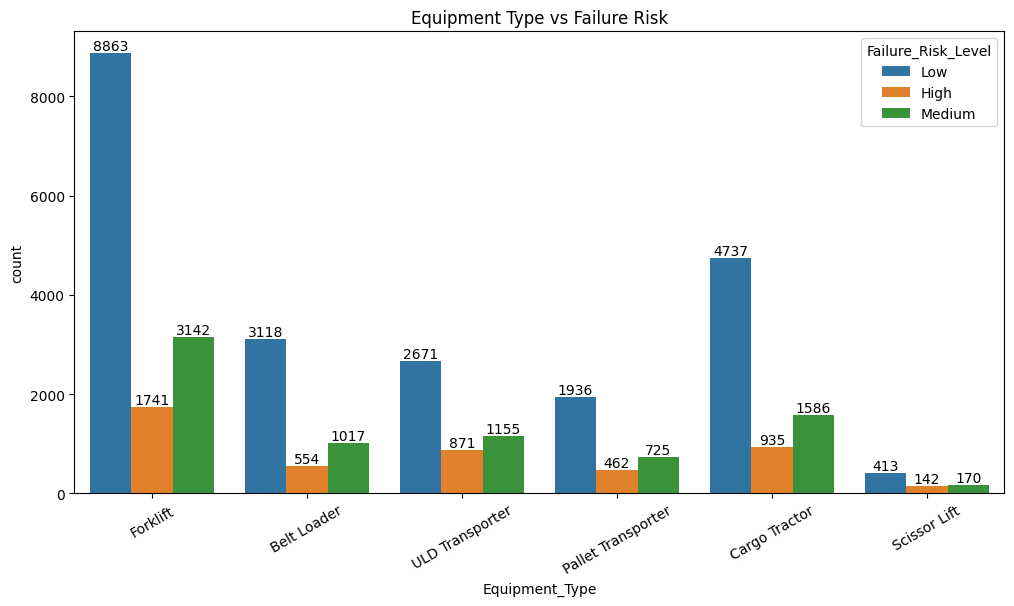

In [251]:
# ====================================
# 4.2 EQUIPMENT TYPE VS FAILURE RISK
# ====================================

plt.figure(figsize=(12,6))

ax = sns.countplot(
    x='Equipment_Type',
    hue='Failure_Risk_Level',
    data=dataset
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Equipment Type vs Failure Risk')

plt.xticks(rotation=30)

plt.show()

4.3 Operating Hours by Failure Risk


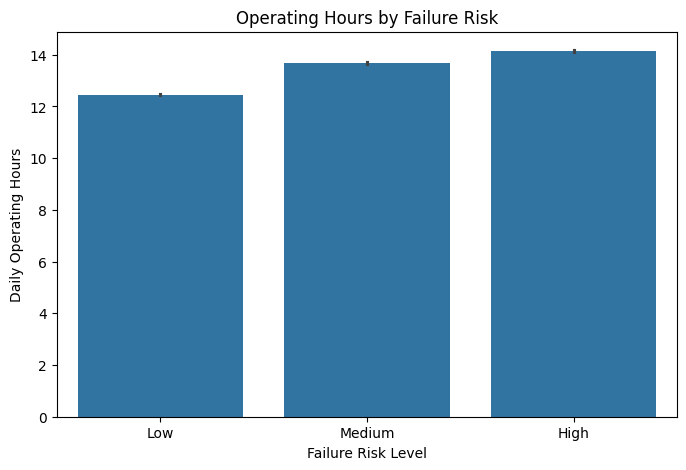

In [252]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Failure_Risk_Level',
    y='Daily_Operating_Hours',
    data=dataset,
    order=['Low','Medium','High']
)

plt.title('Operating Hours by Failure Risk')
plt.xlabel('Failure Risk Level')
plt.ylabel('Daily Operating Hours')

plt.show()

4.4 Equipment Age vs Failure risk

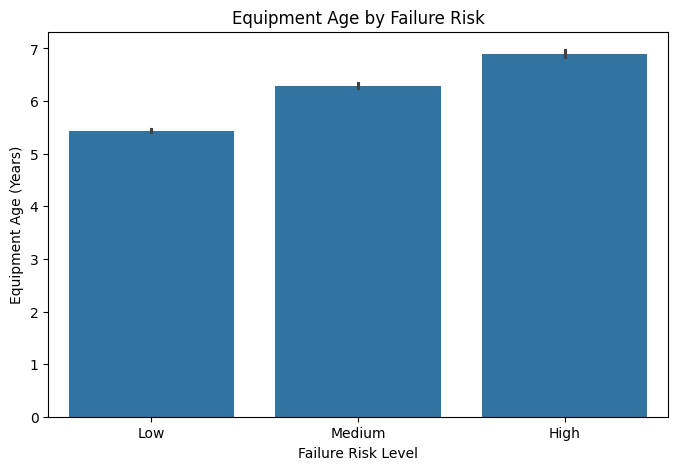

In [253]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Failure_Risk_Level',
    y='Equipment_Age_Year',
    data=dataset,
    order=['Low','Medium','High']
)

plt.title('Equipment Age by Failure Risk')
plt.xlabel('Failure Risk Level')
plt.ylabel('Equipment Age (Years)')

plt.show()

4.5 Month-Wise Failure risk trend


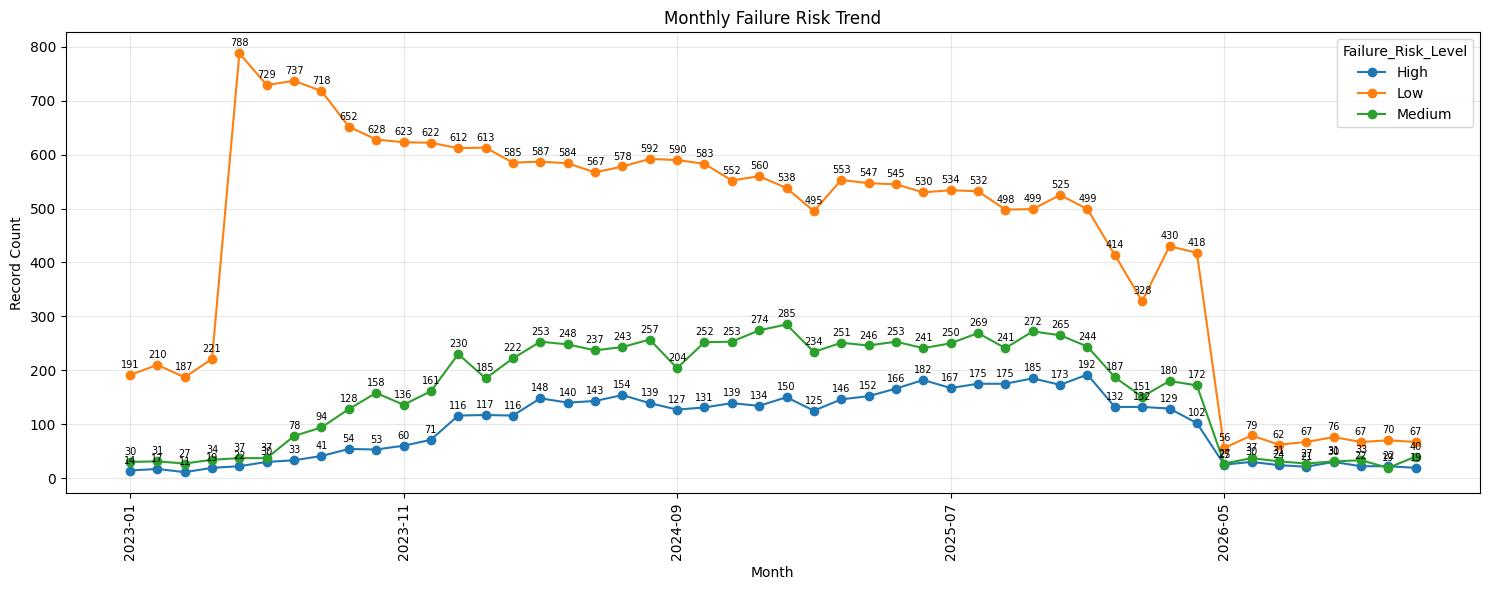

In [254]:
# Convert date column
dataset['Record_Date'] = pd.to_datetime(
    dataset['Record_Date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# Create Month-Year column
dataset['Month_Year'] = dataset['Record_Date'].dt.strftime('%Y-%m')

# Count risk levels by month
monthly_risk = pd.crosstab(
    dataset['Month_Year'],
    dataset['Failure_Risk_Level']
)

# Plot
ax = monthly_risk.plot(
    figsize=(15,6),
    marker='o'
)

plt.title('Monthly Failure Risk Trend')
plt.xlabel('Month')
plt.ylabel('Record Count')

# Show values on line points
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        plt.annotate(
            str(int(y)),
            (x, y),
            textcoords="offset points",
            xytext=(0,5),
            ha='center',
            fontsize=7
        )

plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

**5. Feature Engineering**

5.1 Dataset Splitting


In [255]:
dataset['Record_Date'] = pd.to_datetime(
    dataset['Record_Date']
)
dataset['Year'] = dataset['Record_Date'].dt.year
dataset['Month'] = dataset['Record_Date'].dt.month
dataset['Quarter'] = dataset['Record_Date'].dt.quarter


In [256]:
# Columns to Drop
drop_columns = [
    'Manufacturer',
    'Failure_Risk_Level',
    'Record_Date',
    'Fuel_Type',
    'Month_Year',
    'Fleet_Category',
    'Equipment_Type',
    'Warehouse_Zone'
]

# Features
X = dataset.drop(drop_columns, axis=1)

# Target
y = dataset['Failure_Risk_Level']

# Check Shape
print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (34238, 18)
y Shape : (34238,)


In [257]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_val   :", X_val.shape)
print("X_test  :", X_test.shape)

X_train : (23966, 18)
X_val   : (5136, 18)
X_test  : (5136, 18)


In [258]:
# Backup for CatBoost
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

y_train_cat = y_train.copy()
y_val_cat = y_val.copy()
y_test_cat = y_test.copy()

In [259]:
X_train_cat

,Equipment_ID,Equipment_Age_Year,Daily_Operating_Hours,ULD_Handling_Count,Consecutive_Working_Days,Cargo_Weight_Handled_KG,Overload_Event_Count,Breakdown_Count_6M,Operator_Experience_Years,Battery_Status,Hydraulic_Leak_Observed,Outdoor_Usage,Warning_Indicator_Count,Downtime_Hours_Last_30D,Peak_Hour_Operations,Year,Month,Quarter
2075,F-021,5.6,14,32,12,10240,8,19,14,Good,No,No,3,5,No,2023,7,3
34015,F-010,7.4,13,75,14,45750,8,216,4,Good,Yes,Yes,8,7,Yes,2026,4,2
16490,UT-061,5.8,15,74,18,31228,6,78,15,Good,Yes,No,8,3,Yes,2024,7,3
5553,PT-077,7.3,13,47,15,23030,7,23,1,Good,Yes,No,8,5,Yes,2023,10,4
17498,PT-084,6.3,15,73,16,22338,6,69,15,Good,No,No,5,9,Yes,2024,8,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3621,F-008,4.6,12,46,11,30406,6,21,1,Good,Yes,Yes,8,3,No,2023,8,3
3561,F-009,2.5,10,50,16,30700,5,23,9,Weak,No,No,1,0,Yes,2023,8,3
18292,F-022,3.1,12,70,13,31010,6,122,11,Good,No,Yes,6,0,Yes,2024,4,2
24109,CT-045,4.4,12,67,16,23785,8,122,9,Good,Yes,Yes,8,4,No,2025,9,3


In [260]:
categorical_features = X_train.select_dtypes(
    include=['object','category']
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nTotal Categorical Features:")
print(len(categorical_features))

Categorical Features:
['Equipment_ID', 'Battery_Status', 'Hydraulic_Leak_Observed', 'Outdoor_Usage', 'Peak_Hour_Operations']

Total Categorical Features:
5


C:\Users\BalajiChitrarasu\AppData\Local\Temp\ipykernel_14392\2902459003.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [261]:
feature_encoders = {}

for column in categorical_features:
    le = LabelEncoder()
    X_train[column] = le.fit_transform(X_train[column])
    X_val[column] = le.transform(X_val[column])
    X_test[column] = le.transform(X_test[column])
    feature_encoders[column] = le

print("Input Features Encoded Successfully")

Input Features Encoded Successfully


In [262]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)
print(label_encoder.classes_)

['High' 'Low' 'Medium']


In [263]:
X_train

,Equipment_ID,Equipment_Age_Year,Daily_Operating_Hours,ULD_Handling_Count,Consecutive_Working_Days,Cargo_Weight_Handled_KG,Overload_Event_Count,Breakdown_Count_6M,Operator_Experience_Years,Battery_Status,Hydraulic_Leak_Observed,Outdoor_Usage,Warning_Indicator_Count,Downtime_Hours_Last_30D,Peak_Hour_Operations,Year,Month,Quarter
2075,55,5.6,14,32,12,10240,8,19,14,1,0,0,3,5,0,2023,7,3
34015,44,7.4,13,75,14,45750,8,216,4,1,1,1,8,7,1,2026,4,2
16490,75,5.8,15,74,18,31228,6,78,15,1,1,0,8,3,1,2024,7,3
5553,61,7.3,13,47,15,23030,7,23,1,1,1,0,8,5,1,2023,10,4
17498,68,6.3,15,73,16,22338,6,69,15,1,0,0,5,9,1,2024,8,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3621,42,4.6,12,46,11,30406,6,21,1,1,1,1,8,3,0,2023,8,3
3561,43,2.5,10,50,16,30700,5,23,9,2,0,0,1,0,1,2023,8,3
18292,56,3.1,12,70,13,31010,6,122,11,1,0,1,6,0,1,2024,4,2
24109,19,4.4,12,67,16,23785,8,122,9,1,1,1,8,4,0,2025,9,3


**6. Model Building**

6.1 Random Forest

In [264]:
rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Train Model

rf_model.fit(X_train, y_train_encoded)

# Validation Prediction

y_val_pred_rf = rf_model.predict(X_val)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [265]:
# Accuracy
rf_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_rf
)

# F1 Score
rf_f1 = f1_score(
    y_val_encoded,
    y_val_pred_rf,
    average='weighted'
)
rf_recall = recall_score(
    y_val_encoded,
    y_val_pred_rf,
    average='weighted'
)
rf_precision = precision_score(
    y_val_encoded,
    y_val_pred_rf,
    average='weighted'
)

print("Accuracy :", rf_accuracy)
print("Precision :", rf_precision)
print("Recall :", rf_recall)
print("F1 Score :", rf_f1)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        y_val_encoded,
        y_val_pred_rf
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_encoded,
        y_val_pred_rf
    )
)

Accuracy : 0.9191978193146417
Precision : 0.9190928157447202
Recall : 0.9191978193146417
F1 Score : 0.9175469061909126

Confusion Matrix:

[[ 551   64   90]
 [   7 3195   59]
 [  22  173  975]]

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.78      0.86       705
           1       0.93      0.98      0.95      3261
           2       0.87      0.83      0.85      1170

    accuracy                           0.92      5136
   macro avg       0.92      0.86      0.89      5136
weighted avg       0.92      0.92      0.92      5136



6.2 Xgboost 

In [266]:
# Initialize Model
xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

# Train Model
xgb_model.fit(
    X_train,
    y_train_encoded
)

# Validation Prediction
y_val_pred_xgb = xgb_model.predict(X_val)

print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [267]:
# Accuracy
xgb_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_xgb
)

# F1 Score
xgb_f1 = f1_score(
    y_val_encoded,
    y_val_pred_xgb,
    average='weighted'
)
xgb_recall = recall_score(
    y_val_encoded,
    y_val_pred_xgb,
    average='weighted'
)
xgb_precision = precision_score(
    y_val_encoded,
    y_val_pred_xgb,
    average='weighted'
)

print("Accuracy :", xgb_accuracy)
print("Precision :", xgb_precision)
print("Recall :", xgb_recall)
print("F1 Score :", xgb_f1)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        y_val_encoded,
        y_val_pred_xgb
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_encoded,
        y_val_pred_xgb
    )
)

Accuracy : 0.9505451713395638
Precision : 0.9504958096519235
Recall : 0.9505451713395638
F1 Score : 0.9498219837147279

Confusion Matrix:

[[ 596   64   45]
 [   7 3221   33]
 [  18   87 1065]]

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.85      0.90       705
           1       0.96      0.99      0.97      3261
           2       0.93      0.91      0.92      1170

    accuracy                           0.95      5136
   macro avg       0.95      0.91      0.93      5136
weighted avg       0.95      0.95      0.95      5136



6.3 LightGBM 

In [268]:
# Initialize Model
lgbm_model = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# Train Model
lgbm_model.fit(
    X_train,
    y_train_encoded
)

# Validation Prediction
y_val_pred_lgbm = lgbm_model.predict(X_val)

print("LightGBM Model Trained Successfully")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001344 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 902
[LightGBM] [Info] Number of data points in the train set: 23966, number of used features: 18
[LightGBM] [Info] Start training from score -1.984534
[LightGBM] [Info] Start training from score -0.454289
[LightGBM] [Info] Start training from score -1.479920
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

In [269]:
lgbm_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred_lgbm
)

lgbm_f1 = f1_score(
    y_val_encoded,
    y_val_pred_lgbm,
    average='weighted'
)
lgbm_recall = recall_score(
    y_val_encoded,
    y_val_pred_lgbm,
    average='weighted'
)
lgbm_precision = precision_score(
    y_val_encoded,
    y_val_pred_lgbm,
    average='weighted'
)

print("Accuracy :", lgbm_accuracy)
print("Precision :", lgbm_precision)
print("Recall :", lgbm_recall)
print("F1 Score :", lgbm_f1)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        y_val_encoded,
        y_val_pred_lgbm
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_encoded,
        y_val_pred_lgbm
    )
)

Accuracy : 0.9524922118380063
Precision : 0.952534657061669
Recall : 0.9524922118380063
F1 Score : 0.9518326395953162

Confusion Matrix:

[[ 596   63   46]
 [   7 3219   35]
 [  15   78 1077]]

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.85      0.90       705
           1       0.96      0.99      0.97      3261
           2       0.93      0.92      0.93      1170

    accuracy                           0.95      5136
   macro avg       0.95      0.92      0.93      5136
weighted avg       0.95      0.95      0.95      5136



6.4 Catboost

In [270]:
cat_features = X_train_cat.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print(cat_features)

['Equipment_ID', 'Battery_Status', 'Hydraulic_Leak_Observed', 'Outdoor_Usage', 'Peak_Hour_Operations']


C:\Users\BalajiChitrarasu\AppData\Local\Temp\ipykernel_14392\4262765685.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train_cat.select_dtypes(


In [271]:
# Initialize Model
cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='MultiClass',
    random_state=42,
    verbose=0
)

# Train Model
cat_model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=cat_features
)

# Validation Prediction
y_val_pred_cat = cat_model.predict(X_val_cat)

# Convert prediction shape
y_val_pred_cat = y_val_pred_cat.flatten()

print("CatBoost Model Trained Successfully")

CatBoost Model Trained Successfully


In [272]:
# =====================================
# CHECK TRAINING FEATURES
# =====================================

print("Shape:")
print(X_train_cat.shape)

print("\nColumns:")
print(X_train_cat.columns.tolist())

print("\nCategorical Feature Indexes:")
print(cat_features)

print(len(X_train_cat.columns.tolist()))

Shape:
(23966, 18)

Columns:
['Equipment_ID', 'Equipment_Age_Year', 'Daily_Operating_Hours', 'ULD_Handling_Count', 'Consecutive_Working_Days', 'Cargo_Weight_Handled_KG', 'Overload_Event_Count', 'Breakdown_Count_6M', 'Operator_Experience_Years', 'Battery_Status', 'Hydraulic_Leak_Observed', 'Outdoor_Usage', 'Warning_Indicator_Count', 'Downtime_Hours_Last_30D', 'Peak_Hour_Operations', 'Year', 'Month', 'Quarter']

Categorical Feature Indexes:
['Equipment_ID', 'Battery_Status', 'Hydraulic_Leak_Observed', 'Outdoor_Usage', 'Peak_Hour_Operations']
18


In [273]:
# Accuracy
cat_accuracy = accuracy_score(
    y_val_cat,
    y_val_pred_cat
)

# Precision
cat_precision = precision_score(
    y_val_cat,
    y_val_pred_cat,
    average='weighted'
)

# Recall
cat_recall = recall_score(
    y_val_cat,
    y_val_pred_cat,
    average='weighted'
)

# F1 Score
cat_f1 = f1_score(
    y_val_cat,
    y_val_pred_cat,
    average='weighted'
)

print("Accuracy :", cat_accuracy)
print("Precision :", cat_precision)
print("Recall :", cat_recall)
print("F1 Score :", cat_f1)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        y_val_cat,
        y_val_pred_cat
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_cat,
        y_val_pred_cat
    )
)

Accuracy : 0.9591121495327103
Precision : 0.9592397504691544
Recall : 0.9591121495327103
F1 Score : 0.9585826103653802

Confusion Matrix:

[[ 611   63   31]
 [   7 3229   25]
 [  11   73 1086]]

Classification Report:

              precision    recall  f1-score   support

        High       0.97      0.87      0.92       705
         Low       0.96      0.99      0.97      3261
      Medium       0.95      0.93      0.94      1170

    accuracy                           0.96      5136
   macro avg       0.96      0.93      0.94      5136
weighted avg       0.96      0.96      0.96      5136



**7. Model Comparision**


In [275]:

results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'XGBoost',
        'LightGBM',
        'CatBoost'
    ],

    'Accuracy': [rf_accuracy, xgb_accuracy, lgbm_accuracy, cat_accuracy],
    'Precision': [rf_precision, xgb_precision, lgbm_precision, cat_precision],

    'Recall': [rf_recall, xgb_recall, lgbm_recall, cat_recall],

    'F1 Score': [rf_f1, xgb_f1, lgbm_f1, cat_f1]})

results = results.sort_values(
    by='F1 Score',
    ascending=False
)

results

,Model,Accuracy,Precision,Recall,F1 Score
3,CatBoost,0.959112,0.959240,0.959112,0.958583
2,LightGBM,0.952492,0.952535,0.952492,0.951833
1,XGBoost,0.950545,0.950496,0.950545,0.949822
0,Random Forest,0.919198,0.919093,0.919198,0.917547


**8. Feature Importance**

In [276]:
feature_importance = pd.DataFrame({
    'Feature': X_train_cat.columns,
    'Importance': cat_model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
10,Hydraulic_Leak_Observed,27.613686
4,Consecutive_Working_Days,10.474939
1,Equipment_Age_Year,9.324986
5,Cargo_Weight_Handled_KG,9.201649
2,Daily_Operating_Hours,8.800178
13,Downtime_Hours_Last_30D,8.632326
12,Warning_Indicator_Count,6.449936
11,Outdoor_Usage,5.566045
3,ULD_Handling_Count,5.305101
14,Peak_Hour_Operations,5.182167


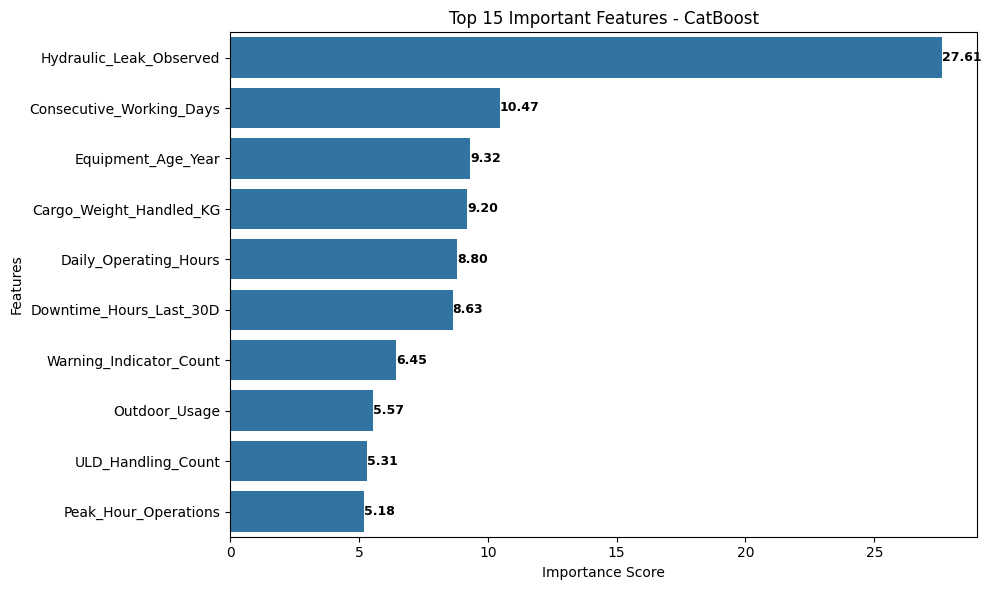

In [277]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

# Add values on bars
for p in ax.patches:

    width = p.get_width()

    ax.annotate(
        f'{width:.2f}',
        (
            width,
            p.get_y() + p.get_height()/2
        ),
        ha='left',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Top 15 Important Features - CatBoost')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

**9. Test the model**

In [278]:
y_test_pred_cat = cat_model.predict(X_test_cat)

y_test_pred_cat = y_test_pred_cat.flatten()

test_accuracy = accuracy_score(
    y_test_cat,
    y_test_pred_cat
)

test_precision = precision_score(
    y_test_cat,
    y_test_pred_cat,
    average='weighted'
)

test_recall = recall_score(
    y_test_cat,
    y_test_pred_cat,
    average='weighted'
)

test_f1 = f1_score(
    y_test_cat,
    y_test_pred_cat,
    average='weighted'
)

print("Test Accuracy :", test_accuracy)
print("Test Precision :", test_precision)
print("Test Recall :", test_recall)
print("Test F1 Score :", test_f1)

Test Accuracy : 0.9587227414330218
Test Precision : 0.958729369740447
Test Recall : 0.9587227414330218
Test F1 Score : 0.9582630284063243


In [279]:
sample = X_test_cat.iloc[[3000]]

prediction = cat_model.predict(sample)

print("Prediction :", prediction)

Prediction : [['Low']]


**10. Save the Model**

In [280]:
with open('model/feature_encoders.pkl', 'wb') as file:
    pickle.dump(feature_encoders, file)

with open('model/catboost_mhe_model.pkl', 'wb') as file:
    pickle.dump(cat_model, file)

print("CatBoost Model Saved Successfully")


CatBoost Model Saved Successfully
